# 03 — Demo, Interpretatie en Presentatie-notebook

## Structuur
1. de pipeline
2. ruwe detecties
3. Effect van NMS
4. Interpretatie
5. Vergelijking YOLO

In [10]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

## Pipeline in woorden

**Training application**
- dataset laden
- CNN trainen
- model evalueren
- model opslaan

**Detection application**
- model laden
- sliding window uitvoeren
- candidate boxes bewaren
- NMS toepassen
- finale boxen tekenen

## demo-afbeeldingen laden
actual = "voor_gridsearch.png"
wanted = "na_gridsearch.png"

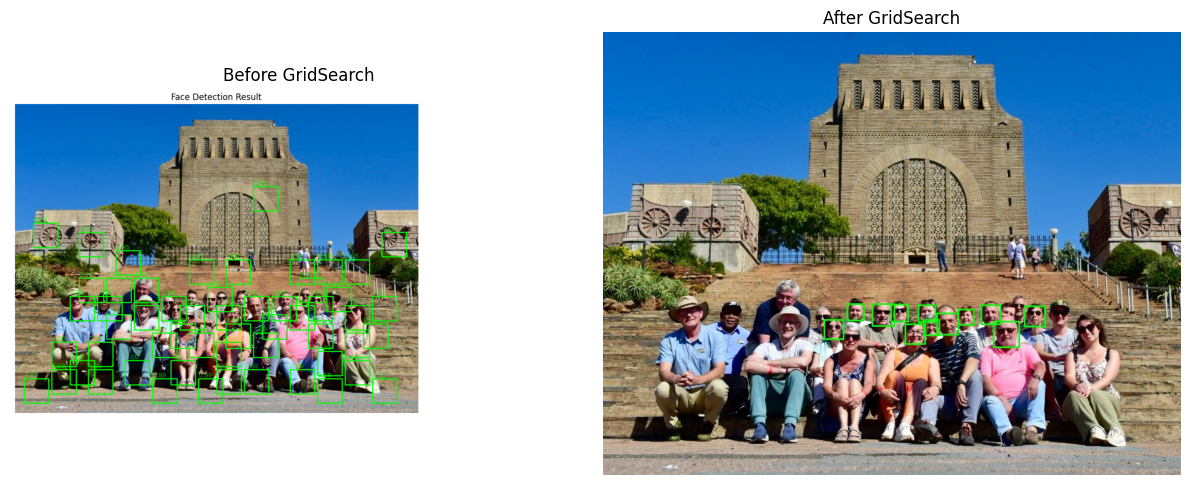

In [13]:
actual = "voor_gridsearch.png"
wanted = "na_gridsearch.png"

if os.path.exists(actual) and os.path.exists(wanted):
    before_img = mpimg.imread(actual)
    after_img = mpimg.imread(wanted)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(before_img)
    plt.title("Before GridSearch")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(after_img)
    plt.title("After GridSearch")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Demo-afbeeldingen niet gevonden. Pas de paden aan indien nodig.")

### Kernzin CNN
> Detectie = classificatie + lokalisatie

### uitleg
> Eerst train ik een CNN classifier op kleine gelabelde beeldjes van faces en non-faces.
> Daarna gebruik ik dat model in een detectie-applicatie.
> Sliding window lokaliseert kandidaatregio's en NMS verwijdert overlappende en redundante detecties.

## Typische beperkingen van deze aanpak

- Sliding window is computationeel duur
- Veel overlappende boxes zonder NMS
- Moeilijker voor meerdere schalen
- Minder efficiënt dan moderne detectiemodellen

Theoretische vergelijking met YOLO

**Sliding Window + CNN**
- eenvoudig te begrijpen
- didactisch sterk
- traag

**YOLO**
- één forward pass
- veel sneller
- productiegerichter

## Eindconclusie

Nu hebben we een volledige AI-pipeline:
- training
- modelopslag
- inferentie
- post-processing
- visualisatie
- resultaatopslag
- interpretatie
- vergelijking met moderne methoden

Duidelijk is dat de 3 model parameters een enorme invloed hebben op de prestaties van het model.µ
De inhoud van de test beelden is ook van groot belang, als er te weinig variatie in zit zal het model niet goed kunnen generaliseren. Ook de verhouding van het aantal face / no face beelden zelf zijn van groot belang en de face beelden moeten zo duidelijk mogelijk een gezicht weergeven. De CNN heeft voldoende variatie nodig om te kunnen generaliseren.

Dit vond ik heel moeilijk te bekomen => als het niet goed was zag je dat dadelijk aan de confusion matrix, er verschenen heel weing true negatives en heel veel true positives. De juiste balans vinden is cruciaal voor een goed presterend model.

Het implementeren van een gridsearchCV zal helpen bij het kiezen van waardes te gebruiken in de CNN, maar omdat dit immens lang duurt alvoorens het resultaten gaf, en die tijd had ik niet, heb ik een mini-gridsearch als voorbeeld gegeven, zie 2bis. 

Ik heb uiteindelijk manueel de parameters aangepast en telkens de confusion matrix geanalyseerd om te zien of er verbetering was. Nu heb ik volgens mij een redelijk presterend model kunnen trainen dat weinig overfitting vertoont, wat blijkt uit de confusion matrix en de scores van de classificatie rapporten. 

De scores zijn vrij hoog en de confusion matrix toont een goede balans tussen true positives en true negatives, wat aangeeft dat het model goed generaliseert naar nieuwe data.

Toch is het model zoals het nu is niet bruikbaar door het aantal false positives dat te groot is, ik zal de tijd nodig hebben om een volledige gridsearchCV uit te voeren om betere parameters te vinden, maar dat is helaas niet mogelijk binnen de tijd die ik had, ik heb na 1 uur het process gestopt.